# Intelligent Talent Search System
## NLP-Powered Multimodal Candidate Ranking for Senior Network Security Roles

---

**Author:** Sebastian Yair Mucito Nájera
**Domain:** Natural Language Processing · Information Retrieval · LLM Applications
**Stack:** Python · sentence-transformers · ChromaDB · pytesseract · pdfplumber · Ollama / Claude API

> This notebook implements an end-to-end intelligent talent search system.
> It reads a real job posting, ingests a corpus of 20 anonymized synthetic CVs
> in mixed formats (PDF + PNG), builds a persistent vector database, and ranks
> candidates by semantic similarity — generating LLM-powered justifications
> for the top-5 recommendations.
>
> **Use case:** Supporting HR teams with an initial AI-assisted screening layer
> for Senior Network Security positions. The system acts as a decision-support
> tool, not a replacement for human judgment.

**Author:** Sebastian Yair Mucito Nájera
[GitHub](https://github.com/smuciton/nlp-intelligent-talent-search) · [LinkedIn](https://linkedin.com/in/smuciton)

This project demonstrates a complete NLP pipeline for intelligent talent search.
A real job posting is used as the semantic query against a corpus of 20 anonymized
synthetic CVs stored in mixed formats (PDF + PNG). Candidates are ranked using
dense semantic embeddings and a ChromaDB vector store, following the
**RAG (Retrieval-Augmented Generation)** pattern to produce explainable results.

## Table of Contents

1. [Job Posting — Target Role](#section-1)
2. [Synthetic CV Corpus — Design & Privacy](#section-2)
3. [System Pipeline](#section-3)
4. [Technical Report & Evaluation](#section-4)
5. [Proposed Improvements](#section-5)
6. [Conclusions](#section-6)

<a id="section-1"></a>

## 1. Job Posting — Target Role

| Field | Detail |
|---|---|
| **Company** | ??? |
| **Role** | Consulting Systems Engineer |
| **Type** | Full-time · International |
| **Domain** | Network Security · SASE · Pre-Sales |
| **Key Skills** | FortiGate · SD-WAN · ZTNA · SASE · SSE · SWG · CASB · BGP/OSPF · IAM |

A real job posting published on Linkedin
is used as the semantic anchor of the system.

This role was selected because it requires a very specific and verifiable technical profile
(SASE, ZTNA, SD-WAN, pre-sales engineering), which makes it easy to validate whether the
system correctly surfaces relevant candidates (Network Security Engineers, SASE Architects)
and filters out unrelated profiles (BI Analysts, Data Engineers, generic Software Developers).

The full job description below is stored as a string and used as the **query** throughout the pipeline.

In [1]:
# Full job description — stored as a string and used as the semantic query
# throughout the pipeline. Every candidate CV is compared against this text.

vacante = """
Consulting Systems Engineer - Fortinet

Job Duties and responsibilities:
Support International sales activities as a strategic and high-level corporate technical
resource for vital pre-sales engagements and key opportunities.
Act as subject-matter expert in pre-sales design reviews and serve as authoritative
consultant to Field Systems Engineers by providing technical guidance and leadership.
Participate with SE peers to lead the design and architecture of secure IP networks
utilizing and leveraging all aspects of Fortinet's product line.
Provide training to System Engineers at various events worldwide and mentor SE specialists.
Serve as Virtual Team Leaders representing the International Sales Organization.
Work closely with Product Management and Engineering to help identify and develop features.
Write whitepapers, tech notes, and other high-level technical documentation.
Interface with Fortinet's Business and Technology partners.

Skills & Qualifications:
Deep and strong knowledge of Secure Access Service Edge (SASE) architecture and
cloud-delivered security models.
Hands-on experience with Zero Trust Network Access (ZTNA) and identity-based access controls.
Solid experience with SD-WAN technologies: application-aware routing, dynamic path
selection, branch connectivity.
Experience integrating SWG, CASB, FWaaS, DLP within a SASE or SSE framework.
Familiarity with IAM integrations: SAML, OAuth, OIDC, MFA with Azure AD / Entra ID, Okta.
Networking fundamentals: TCP/IP, BGP/OSPF, DNS, NAT, IPsec/SSL VPN.
Experience securing access to SaaS and cloud applications, CASB policies, shadow IT visibility.
Understanding of public cloud networking: AWS, Azure, Google Cloud.
Experience integrating SASE platforms with SIEM, XDR, logging platforms.
Automation and APIs: Python, Terraform, Ansible (plus).
Experience with SASE/SSE platforms: Fortinet, Zscaler, Palo Alto Prisma Access, Netskope, Cisco.
"""

print(vacante[:300], '...')


Consulting Systems Engineer - Fortinet

Job Duties and responsibilities:
Support International sales activities as a strategic and high-level corporate technical
resource for vital pre-sales engagements and key opportunities.
Act as subject-matter expert in pre-sales design reviews and serve as aut ...


<a id="section-2"></a>

## 2. Synthetic CV Corpus — Design & Privacy Rationale

### Privacy by Design

Processing real candidate CVs with AI raises serious privacy concerns regulated by
GDPR (Europe), LFPDPPP (Mexico), and CCPA (California). All 20 CVs in this corpus
are **synthetic and fully anonymized** — they contain no name, photo, gender, age,
nationality, address, or marital status.

This design choice serves multiple purposes:

- **Eliminates algorithmic bias**: embedding models can encode correlations between
  names and demographic attributes, which would propagate unfairness into the ranking.
- **Legal compliance**: removes the need for explicit legal bases required for automated
  decision-making on personal data.
- **Meritocratic evaluation**: the system scores candidates exclusively on skills,
  experience, certifications, and technical domain alignment.
- **Reproducibility**: the anonymized corpus can be shared openly without privacy risk.

### Corpus Composition

| Experience Level | Count | CV IDs | Years of Exp. |
|---|---|---|---|
| **Junior** | 5 | CV01 – CV05 | 0–2 years |
| **Intermediate** | 10 | CV06 – CV15 | 3–6 years |
| **Senior** | 5 | CV16 – CV20 | 7+ years |

| Profile Type | CVs | Relevance to Job Posting |
|---|---|---|
| Network Security Engineer / Architect | CV01, CV06, CV09, CV14, CV16 | ⭐⭐⭐⭐⭐ Very High |
| Security Engineer / Cybersecurity | CV02, CV08, CV17, CV20 | ⭐⭐⭐⭐ High |
| Cloud Security / DevSecOps | CV03, CV07, CV10, CV18 | ⭐⭐⭐⭐ High |
| IT Systems Engineer (generalist) | CV11 | ⭐⭐⭐ Medium |
| Software Developer / Architect | CV04, CV12, CV19 | ⭐⭐ Low |
| Data / BI Analyst | CV05, CV13, CV15 | ⭐ Very Low |

**File formats:** 16 PDFs + 4 PNGs — this mix tests the system's multimodal ingestion capability.

### CV Generation Prompt

The synthetic CVs were generated using an LLM with the following prompt.
It is included here for full **reproducibility** of the dataset.

In [33]:
# Prompt used to generate the synthetic CV corpus with an LLM.
# Included here for full reproducibility of the dataset.

cv_generation_prompt = """
Generate 20 synthetic and anonymous CVs to evaluate a talent search system.
Do NOT include: name, photo, gender, age, nationality, address, marital status,
or any personally identifiable information (PII).

Each CV must include:
- Professional summary
- Education / Academic background
- Work experience
- Technical skills
- Soft skills
- Certifications
- Languages
- Relevant projects

Experience level distribution:
- Junior       : 5 profiles, 0 to 2 years of experience.
- Intermediate : 10 profiles, 3 to 6 years of experience.
- Senior       : 5 profiles, 7 or more years of experience.

Generate varied profiles — some closely aligned and some less aligned with the
Fortinet Consulting Systems Engineer job posting.
Include profiles related to: cybersecurity, network security, cloud security,
SASE/SSE, SD-WAN, IAM, automation, solution architecture, systems engineering,
pre-sales support, and technical documentation.
"""

print(cv_generation_prompt)


Generate 20 synthetic and anonymous CVs to evaluate a talent search system.
Do NOT include: name, photo, gender, age, nationality, address, marital status,
or any personally identifiable information (PII).

Each CV must include:
- Professional summary
- Education / Academic background
- Work experience
- Technical skills
- Soft skills
- Certifications
- Languages
- Relevant projects

Experience level distribution:
- Junior       : 5 profiles, 0 to 2 years of experience.
- Intermediate : 10 profiles, 3 to 6 years of experience.
- Senior       : 5 profiles, 7 or more years of experience.

Generate varied profiles — some closely aligned and some less aligned with the
Fortinet Consulting Systems Engineer job posting.
Include profiles related to: cybersecurity, network security, cloud security,
SASE/SSE, SD-WAN, IAM, automation, solution architecture, systems engineering,
pre-sales support, and technical documentation.



<a id="section-3"></a>

## 3. System Pipeline

The system follows the **RAG (Retrieval-Augmented Generation)** pattern:
a vector database retrieves the most semantically similar CVs to the job posting,
and an LLM generates natural-language justifications for each recommendation.
No fine-tuning is required — the embedding model is used off-the-shelf.

The pipeline processes CVs in two formats (PDF and PNG), extracts their text,
generates semantic embeddings, and stores them in a ChromaDB vector database.
At query time, the job posting is embedded in the same space and the k nearest
CV vectors are retrieved by cosine similarity.

**Steps:**

1. Read each CV — PDF via `pdfplumber`, PNG via `pytesseract` OCR.
2. Clean and normalize text (lowercase, remove separators and stopwords).
3. Generate dense embeddings with `sentence-transformers`.
4. Index all CVs in a persistent ChromaDB collection.
5. Encode the job posting and retrieve the k=5 nearest neighbors.
6. Build a structured prompt and generate candidate justifications via LLM.

```
MULTIMODAL TALENT SEARCH PIPELINE
=======================================================================

STEP 1-2  DOCUMENT INGESTION
  -----------------------------------------------------------------------
  |  read_pdf()          read_png()           extract_level()          |
  |  pdfplumber           pytesseract OCR      filters non-CV files    |
  |  16 files             4 files              by CV number range      |
  -----------------------------------------------------------------------
                                |
                                v
  cv_data: raw text + level + profile + format
                                |
                                v
STEP 3  TEXT PREPROCESSING
  -----------------------------------------------------------------------
  |  clean_text()                                                       |
  |  lowercase, strip separators, remove English stopwords              |
  -----------------------------------------------------------------------
                                |
                                v
STEP 4  EMBEDDINGS + VECTOR DATABASE
  -----------------------------------------------------------------------
  |  SentenceTransformer('all-MiniLM-L6-v2')                           |
  |                         |                                           |
  |                         v                                           |
  |  collection.add()  ->  ChromaDB persistent store                   |
  -----------------------------------------------------------------------
                                |
                                v
STEP 5-6  SEMANTIC RETRIEVAL
  -----------------------------------------------------------------------
  job_posting  -->  retrieve_candidates(query, k)                       |
  |                   collection.query() · cosine distance              |
  -----------------------------------------------------------------------
                                |
                                v
  df_ranking: all 20 CVs ordered by similarity score
                                |
                                v
STEP 7  LLM-POWERED JUSTIFICATION
  -----------------------------------------------------------------------
  |  build_prompt(cv_info, job_posting)                                 |
  |                         |                                           |
  |   Option A         Option B          Fallback                       |
  |   Claude API       Ollama local      rule-based (no LLM)            |
  |       \               |                /                           |
  |        \______________|______________/                             |
  |                       v                                             |
  |   generate_response()  ->  natural language justification           |
  -----------------------------------------------------------------------
                                |
                                v
  OUTPUT: Top-5 candidates with score, level, profile and justification
=======================================================================
```

### 3.0 — Dependencies & Installation

In [6]:
# Dependency setup — resolves Pillow / pdfplumber version conflicts in Colab.
# IMPORTANT: Run this cell first, then restart the runtime before proceeding.

# Step 1: Remove conflicting package versions.
#!pip uninstall -y pdfplumber scikit-image || true

# Step 2: Install a Pillow version compatible with pdfplumber 0.7.x.
!pip install Pillow==9.5.0 --force-reinstall

# Step 3: Install core libraries — pdfplumber pinned for compatibility.
!pip install -q chromadb sentence-transformers pdfplumber==0.7.0 pytesseract

# Step 4: Install Tesseract OCR engine (required for PNG text extraction).
!apt-get -qq install -y tesseract-ocr > /dev/null


  Using cached Pillow-9.5.0-cp312-cp312-linux_x86_64.whl
  Attempting uninstall: Pillow
    Found existing installation: Pillow 9.5.0
    Uninstalling Pillow-9.5.0:
      Successfully uninstalled Pillow-9.5.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.3.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.43.0 which is incompatible.
google-adk 2.3.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.43.0 which is incompatible.


In [7]:
import os
import re
import glob

import pdfplumber
import pytesseract
from PIL import Image

from sentence_transformers import SentenceTransformer
import chromadb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### 3.1 — Environment Setup & Drive Mount

Mount Google Drive and configure the paths to the CV corpus and ChromaDB storage.
Update `BASE_DIR` to match your own Drive folder structure before running.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Update these paths to match your Google Drive folder structure.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/TC5060-NLP/Semana 9/"
CV_DIR   = f"{BASE_DIR}/CVs Genericos LLM Gemini"
CHROMA_DIR = f"{BASE_DIR}/chroma_talento"

os.makedirs(CHROMA_DIR, exist_ok=True)

print("CV directory   :", CV_DIR)
print("ChromaDB path  :", CHROMA_DIR)

Mounted at /content/drive
CV directory   : /content/drive/MyDrive/Colab Notebooks/MNA/TC5060-NLP/Semana 9//CVs Genericos LLM Gemini
ChromaDB path  : /content/drive/MyDrive/Colab Notebooks/MNA/TC5060-NLP/Semana 9//chroma_talento


In [9]:
# Scan the CV directory and list all PDF and PNG files found.

pdfs = sorted(glob.glob(os.path.join(CV_DIR, "*.pdf")))
pngs = sorted(glob.glob(os.path.join(CV_DIR, "*.png")))

print(f"PDFs  : {len(pdfs)}")
print(f"PNGs  : {len(pngs)}")
print(f"Total : {len(pdfs) + len(pngs)}  (expected: 20)")

todos = pdfs + pngs
for f in todos:
    print(' -', os.path.basename(f))

PDFs  : 16
PNGs  : 4
Total : 20  (expected: 20)
 - CV_01_Junior_Network_Security_Engineer.pdf
 - CV_03_Junior_Data_Scientist.pdf
 - CV_04_Junior_Software_Developer.pdf
 - CV_05_Junior_BI_Analyst.pdf
 - CV_06_Network_Security_Engineer.pdf
 - CV_08_Pre-Sales_Systems_Engineer.pdf
 - CV_09_Cloud_Security_Engineer.pdf
 - CV_10_Technical_Security_Consultant.pdf
 - CV_12_Data_Engineer.pdf
 - CV_13_Software_Developer.pdf
 - CV_14_Automation_API_Engineer.pdf
 - CV_15_BI_Analyst.pdf
 - CV_16_Consulting_Systems_Engineer.pdf
 - CV_18_Senior_Network_Security_Engineer.pdf
 - CV_19_Senior_Software_Architect.pdf
 - CV_20_Senior_Machine_Learning_Engineer.pdf
 - Code_Generated_Image (1).png
 - Code_Generated_Image (2).png
 - Code_Generated_Image (3).png
 - Code_Generated_Image.png


### 3.2 — Multimodal Text Extraction (PDF + PNG/OCR)

The corpus intentionally mixes two file formats to test multimodal ingestion:

- **PDF files (16):** text extracted directly via `pdfplumber` — clean, lossless.
- **PNG files (4):** rendered CV images processed via `pytesseract` OCR.
  OCR typically introduces some noise (split words, stray characters),
  which is handled in the preprocessing step.

In [10]:
def leer_pdf(ruta):
    """Extract full text from a PDF by concatenating all pages."""
    texto = ""
    with pdfplumber.open(ruta) as pdf:
        for pagina in pdf.pages:
            t = pagina.extract_text()
            if t:
                texto += t + "\n"
    return texto


def leer_png(ruta):
    """Extract text from a PNG image using Tesseract OCR."""
    img = Image.open(ruta)
    # PSM 6: assume a uniform block of text — suitable for CV images.
    texto = pytesseract.image_to_string(img, config="--psm 6")
    return texto

In [11]:
# Process all CV files — extract text and parse metadata from the filename.

cv_data = []

for ruta in todos:
    nombre = os.path.basename(ruta)
    ext = nombre.split('.')[-1].lower()

    if ext == 'pdf':
        texto = leer_pdf(ruta)
        formato = 'PDF'
    else:
        texto = leer_png(ruta)
        formato = 'PNG (OCR)'

    # Use the full filename (without extension) as a unique document ID.
    base_nombre = nombre.replace(f'.{ext}','')
    partes = base_nombre.split('_')

    cv_id = base_nombre # Usamos el nombre base como ID único
    nivel = partes[1] if len(partes) > 1 else '?'
    perfil = ' '.join(partes[2:]) if len(partes) > 2 else '?'

    cv_data.append({
        'cv_id': cv_id,
        'nivel': nivel,
        'perfil': perfil,
        'formato': formato,
        'archivo': nombre,
        'texto': texto
    })

    print(f"{cv_id[:6]:6s} [{formato:10s}] -> {len(texto)} caracteres extraídos")

print(f"\nTotal CVs loaded: {len(cv_data)}")

CV_01_ [PDF       ] -> 870 caracteres extraídos
CV_03_ [PDF       ] -> 750 caracteres extraídos
CV_04_ [PDF       ] -> 652 caracteres extraídos
CV_05_ [PDF       ] -> 647 caracteres extraídos
CV_06_ [PDF       ] -> 897 caracteres extraídos
CV_08_ [PDF       ] -> 890 caracteres extraídos
CV_09_ [PDF       ] -> 772 caracteres extraídos
CV_10_ [PDF       ] -> 803 caracteres extraídos
CV_12_ [PDF       ] -> 627 caracteres extraídos
CV_13_ [PDF       ] -> 591 caracteres extraídos
CV_14_ [PDF       ] -> 669 caracteres extraídos
CV_15_ [PDF       ] -> 619 caracteres extraídos
CV_16_ [PDF       ] -> 944 caracteres extraídos
CV_18_ [PDF       ] -> 834 caracteres extraídos
CV_19_ [PDF       ] -> 771 caracteres extraídos
CV_20_ [PDF       ] -> 752 caracteres extraídos
Code_G [PNG (OCR) ] -> 735 caracteres extraídos
Code_G [PNG (OCR) ] -> 730 caracteres extraídos
Code_G [PNG (OCR) ] -> 851 caracteres extraídos
Code_G [PNG (OCR) ] -> 868 caracteres extraídos

Total CVs loaded: 20


In [12]:
# Compare extraction quality: PDF (direct) vs PNG (OCR) — OCR output is noisier.

ejemplo_pdf = next(c for c in cv_data if c['formato']=='PDF')
ejemplo_png = next(c for c in cv_data if c['formato']=='PNG (OCR)')

print("=== PDF extraction sample ===")
print(ejemplo_pdf['texto'][:400])
print("\n=== PNG / OCR extraction sample ===")
print(ejemplo_png['texto'][:400])

=== PDF extraction sample ===
JUNIOR NETWORK SECURITY
ENGINEER
Anonymous Candidate  |  Experience Level: Junior
PROFESSIONAL SUMMARY
Highly motivated network security professional with foundational experience in IP networks and basic
firewall administration. Eager to grow in cloud security and zero-trust architectures.
WORK EXPERIENCE
IT Security Intern, TechCorp (2022-2023): Monitored network traffic using basic SIEM tools; a

=== PNG / OCR extraction sample ===
SECOPS ENGINEER

Anonymous Candidate | Experience Level Semi-Senior

PROFESSIONAL SUMMARY

Proactive SecOps professional with 35 yearsofexperience in threat monitoring,
EDR management and incident response,

WORK EXPERIENCE

‘SecOps Analyst BankSafe(2020-Presentl Monitored XDRand SIEM dashboards
‘managed endpointsecurity using Crowdtrike

EDUCATION

BBS inComputer Science (2018),

TECHNICAL SKILLS


OCR-extracted text contains more noise than PDF-extracted text: irregular line breaks,
misrecognized characters, and merged tokens are common artifacts.
This is expected behavior and is addressed in the preprocessing step.

### 3.3 — Text Preprocessing

A lightweight normalization chain is applied before vectorization:

1. Lowercase all text
2. Strip `===`, `---`, `___` separator lines (CV formatting artifacts)
3. Remove special characters (retain alphanumeric, `.`, `+`, `#`, `/`)
4. Collapse multiple whitespace
5. Remove English stopwords and single-character tokens

Domain-specific terms (SASE, ZTNA, FortiGate, BGP, etc.) are **not** stemmed
to preserve their semantic weight in the network security domain.

In [13]:
# Manually curated English stopword list.
# Avoids external downloads while keeping the pipeline self-contained.

stopwords_en = set('''
a an the and or but in on at to for of with as by from up about into
through during before after above below between out off over under
then once is are was were be been being have has had do does did
will would could should may might must shall can not no nor so yet
this that these those it its he she they we you i him her us them
who what which how when where why all any per via vs etc
'''.split())


def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[=\-_]{3,}', ' ', texto)        # strip separator lines (===, ---, ___)
    texto = re.sub(r'[^a-z0-9\.\+\#/\s]', ' ', texto) # remove special chars, keep . + # /
    texto = re.sub(r'\s+', ' ', texto).strip()
    palabras = [w for w in texto.split() if w not in stopwords_en and len(w) > 1]
    return ' '.join(palabras)


for cv in cv_data:
    cv['texto_limpio'] = limpiar_texto(cv['texto'])

vacante_limpia = limpiar_texto(vacante)

print("Job posting — first 300 chars (cleaned):")
print(vacante_limpia[:300])

Job posting — first 300 chars (cleaned):
consulting systems engineer fortinet job duties responsibilities support international sales activities strategic high level corporate technical resource vital pre sales engagements key opportunities. act subject matter expert pre sales design reviews serve authoritative consultant field systems eng


### 3.4 — Semantic Embeddings & Vector Database

**Model:** `all-MiniLM-L6-v2` (sentence-transformers) — a compact 384-dimensional
model optimized for semantic similarity. It captures conceptual meaning beyond
keyword overlap: a CV mentioning *'cloud-delivered security'* and *'identity-centric access'*
will rank high against a posting using *SASE* and *ZTNA* even without exact term matches.

**Vector store:** ChromaDB with a persistent client, so the collection survives
Colab session restarts without re-embedding all documents.

In [14]:
# Load the sentence embedding model.
# all-MiniLM-L6-v2: 384-dim, fast and well-suited for semantic similarity tasks.

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded — embedding dimension:",
      embedding_model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded — embedding dimension: 384


/tmp/ipykernel_1290/1962971644.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_model.get_sentence_embedding_dimension())


In [15]:
# Initialize ChromaDB with a persistent client.
# The collection is stored on Drive and survives session restarts.

client = chromadb.PersistentClient(path=CHROMA_DIR)
collection = client.get_or_create_collection(name="cvs_fortinet")

print("Collection ready — documents indexed:", collection.count())

Collection ready — documents indexed: 20


In [16]:
# Index all CVs into ChromaDB.
# The guard prevents duplicate inserts if this cell is re-run.

if collection.count() == 0:

    textos = [cv['texto_limpio'] for cv in cv_data]
    ids    = [cv['cv_id'] for cv in cv_data]

    embeddings = embedding_model.encode(textos).tolist()

    # Store level, profile, and format as metadata for post-retrieval filtering.
    metadatas = [
        {'nivel': cv['nivel'], 'perfil': cv['perfil'], 'formato': cv['formato']}
        for cv in cv_data
    ]

    collection.add(
        documents=textos,
        embeddings=embeddings,
        metadatas=metadatas,
        ids=ids
    )

    print(f"{collection.count()} CVs indexed in ChromaDB.")
else:
    print(f"Collection already has {collection.count()} CVs — skipping insert.")

Collection already has 20 CVs — skipping insert.


### 3.5 — Semantic Retrieval Function

The job posting is encoded into the same embedding space and compared against
all indexed CVs using cosine distance. A lower distance means higher semantic
similarity — candidates are ranked from most to least relevant.

In [17]:
def retrieve_candidatos(query, k=5):
    """
    Retrieve the k most semantically similar CVs to a given query text.
    In this pipeline the query is always the cleaned job posting text.
    """
    query_emb = embedding_model.encode([query]).tolist()

    resultados = collection.query(
        query_embeddings=query_emb,
        n_results=k
    )

    return resultados


# Quick sanity check — retrieve top-5 candidates.

resultado = retrieve_candidatos(vacante_limpia, k=5)

for i in range(len(resultado['ids'][0])):
    cv_id = resultado['ids'][0][i]
    meta  = resultado['metadatas'][0][i]
    dist  = resultado['distances'][0][i]
    print(f"{i+1}. {cv_id} | {meta['nivel']:12s} | {meta['perfil']:35s} | dist={dist:.4f}")

1. CV_16_Consulting_Systems_Engineer | 16           | Consulting Systems Engineer         | dist=0.3224
2. CV_06_Network_Security_Engineer | 06           | Network Security Engineer           | dist=0.5685
3. CV_10_Technical_Security_Consultant | 10           | Technical Security Consultant       | dist=0.6114
4. CV_08_Pre-Sales_Systems_Engineer | 08           | Pre-Sales Systems Engineer          | dist=0.6155
5. Code_Generated_Image (3) | Generated    | Image (3)                           | dist=0.6178


ChromaDB returns a **cosine distance** (lower = more similar, 0 = identical).
This is the inverse of the more familiar cosine similarity (higher = more similar, 1 = identical).
The ranking chart below converts distances to similarity scores using `1 − distance`.

### 3.6 — Full Ranking of All 20 CVs

Retrieve all 20 candidates from the vector store to produce a complete ranked list.
This gives a global view of the similarity landscape — making it easy to verify
that high-relevance profiles (Network Security, SASE) rank above low-relevance
profiles (BI Analysts, Data Engineers), as expected by domain knowledge.

In [18]:
resultado_full = retrieve_candidatos(vacante_limpia, k=20)

filas = []
for i in range(len(resultado_full['ids'][0])):
    cv_id = resultado_full['ids'][0][i]
    meta  = resultado_full['metadatas'][0][i]
    dist  = resultado_full['distances'][0][i]
    filas.append({
        'cv_id': cv_id,
        'nivel': meta['nivel'],
        'perfil': meta['perfil'],
        'formato': meta['formato'],
        'distancia': dist
    })

df_ranking = pd.DataFrame(filas).sort_values('distancia').reset_index(drop=True)
df_ranking.index = df_ranking.index + 1

df_ranking

,cv_id,nivel,perfil,formato,distancia
1,CV_16_Consulting_Systems_Engineer,16,Consulting Systems Engineer,PDF,0.322388
2,CV_06_Network_Security_Engineer,06,Network Security Engineer,PDF,0.568477
3,CV_10_Technical_Security_Consultant,10,Technical Security Consultant,PDF,0.611435
4,CV_08_Pre-Sales_Systems_Engineer,08,Pre-Sales Systems Engineer,PDF,0.615487
5,Code_Generated_Image (3),Generated,Image (3),PNG (OCR),0.617798
6,Code_Generated_Image,Generated,Image,PNG (OCR),0.704471
7,Code_Generated_Image (2),Generated,Image (2),PNG (OCR),0.719166
8,CV_18_Senior_Network_Security_Engineer,18,Senior Network Security Engineer,PDF,0.797628
9,CV_09_Cloud_Security_Engineer,09,Cloud Security Engineer,PDF,0.818704
10,CV_01_Junior_Network_Security_Engineer,01,Junior Network Security Engineer,PDF,0.839474


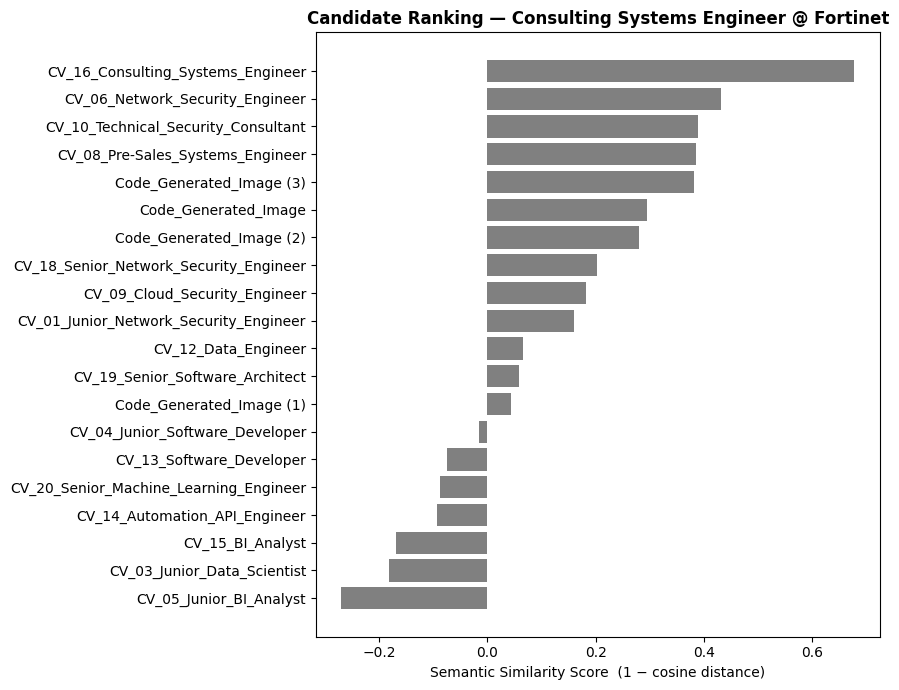

In [39]:
# Horizontal bar chart — similarity score per candidate, colored by experience level.


plt.figure(figsize=(9,7))
plt.barh(df_ranking['cv_id'], 1 - df_ranking['distancia'], color=colores)
plt.gca().invert_yaxis()
plt.xlabel('Semantic Similarity Score  (1 − cosine distance)')
plt.title('Candidate Ranking — Consulting Systems Engineer @ Fortinet',
         fontweight='bold')

# Build legend handles manually from the color map.
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=v, label=k) for k,v in colores_nivel.items()]
#plt.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

### 3.7 — Top-5 Candidates with LLM-Generated Justifications

Following the RAG pattern — **retrieved context + query → LLM → answer** —
the top-5 CV contents are combined with the job posting into a structured prompt,
and an LLM generates a concise natural-language assessment for each candidate.

Three generation backends are available — configure by toggling the flags below:

| Backend | Flag | Requirement |
|---|---|---|
| **Anthropic Claude API** | `USAR_API_CLAUDE = True` | `ANTHROPIC_API_KEY` env variable |
| **Ollama (local LLM)** | `USAR_OLLAMA = True` | Ollama installed + model pulled |
| **Keyword fallback** | both `False` | No external dependency |

In [26]:
# RAG prompt template: context (CV) + query (job posting) -> LLM -> justification.
# IMPORTANT: prompt is fully in English so the LLM always responds in English,
# regardless of the language mix in the CV text.

def construir_prompt(cv_info, vacante_texto):
    return f"""You are a senior technical recruiter specializing in network security and cybersecurity.
You will be given a job posting and a candidate's CV.
Your task is to write 3-4 sentences in ENGLISH explaining whether this candidate
is a strong match for the role and why, citing specific technical skills that align.
Always respond in English only.

JOB POSTING:
{vacante_texto[:600]}

CANDIDATE CV ({cv_info['cv_id']}, {cv_info['nivel']} level):
{cv_info['texto'][:1200]}

ASSESSMENT (in English):
"""

In [27]:
# Option A: Anthropic Claude API.
# Set USAR_API_CLAUDE = True and add ANTHROPIC_API_KEY as a Colab secret.

USAR_API_CLAUDE = False   # cambiar a True si se tiene la API key

if USAR_API_CLAUDE:
    !pip install -q anthropic
    import anthropic

    cliente = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from environment

    def generar_respuesta(prompt):
        msg = cliente.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=250,
            messages=[{"role": "user", "content": prompt}]
        )
        return msg.content[0].text

In [31]:
# Option B: Ollama — local LLM, no API key required.
# Installs Ollama in the Colab environment and pulls a small local model.

USAR_OLLAMA = True   # cambiar a True si se va a usar Ollama local

if USAR_OLLAMA:
    # Install zstd (required by the Ollama installer).
    !apt-get install -y zstd
    !curl -fsSL https://ollama.com/install.sh | sh
    import subprocess, time
    subprocess.Popen(['ollama', 'serve'])
    time.sleep(3)
    !ollama pull qwen2.5:0.5b

    import requests

    def generar_respuesta(prompt):
        r = requests.post('http://localhost:11434/api/generate',
                           json={'model': 'qwen2.5:0.5b', 'prompt': prompt, 'stream': False})
        return r.json()['response']

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.



In [29]:
# Fallback: deterministic keyword-based scoring.
# Used when no LLM backend is active — NOT a replacement for a real LLM.
# Scans the CV text for key terms from the job posting and returns a summary.

if not USAR_API_CLAUDE and not USAR_OLLAMA:

    KEY_TERMS = ['sase','ztna','sd-wan','sdwan','fortigate','fortinet',
                 'casb','swg','firewall','bgp','ospf','vpn','zscaler',
                 'palo alto','okta','saml','presales','pre-sales']

    def generar_respuesta(prompt):
        # Extract the CV block from the prompt and scan for domain key terms.
        cv_block = prompt.split('CANDIDATE CV')[-1].lower()
        matched = [t for t in KEY_TERMS if t in cv_block]
        if matched:
            return (f"Candidate matches key domain terms: {', '.join(matched[:6])}. "
                    "This indicates relevant experience in network security and/or SASE, "
                    "which aligns with the Fortinet job requirements.")
        else:
            return ("No key terms from the job posting were found in this CV — "
                    "low match likelihood for this role.")

    print("Using keyword fallback — no external LLM backend active.")

In [32]:
# Retrieve top-5 candidate IDs from the ranked DataFrame.
top5_ids = df_ranking.head(5)['cv_id'].tolist()

print("="*65)
print("  TOP-5 RECOMMENDED CANDIDATES — Consulting Systems Engineer @ Fortinet")
print("="*65)

for pos, cv_id in enumerate(top5_ids, 1):
    cv_info = next(c for c in cv_data if c['cv_id'] == cv_id)
    fila = df_ranking[df_ranking['cv_id']==cv_id].iloc[0]

    prompt = construir_prompt(cv_info, vacante)
    justificacion = generar_respuesta(prompt)

    print(f"\n  #{pos}  {cv_id}  |  {fila['nivel']}  |  {fila['formato']}")
    print(f"  Profile    : {fila['perfil']}")
    print(f"  Similarity : {1 - fila['distancia']:.4f}  (distance: {fila['distancia']:.4f})")
    print("  Assessment :")
    print(justificacion)
    print("-"*65)

  TOP-5 RECOMMENDED CANDIDATES — Consulting Systems Engineer @ Fortinet

  #1  CV_16_Consulting_Systems_Engineer  |  16  |  PDF
  Profile    : Consulting Systems Engineer
  Similarity : 0.6776  (distance: 0.3224)
  Assessment :
**Strong Match for the Role:**
The candidate's extensive experience in leading design reviews, partnering with Product Management, managing MSSP technical relationships, and delivering training to a global audience aligns well with the consulting systems engineer position at Fortinet. Their background and expertise make them ideal candidates for this role, particularly their strong technical leadership, ability to effectively communicate with both SE peers and external stakeholders, and experience in commercial mindset.

**Why They Are Considered Strong:**
- **Technical Leadership:** The candidate demonstrated a proven track record of delivering technical guidance and serving as an authoritative consultant. Their involvement with the SASE (Service Now Access Ser

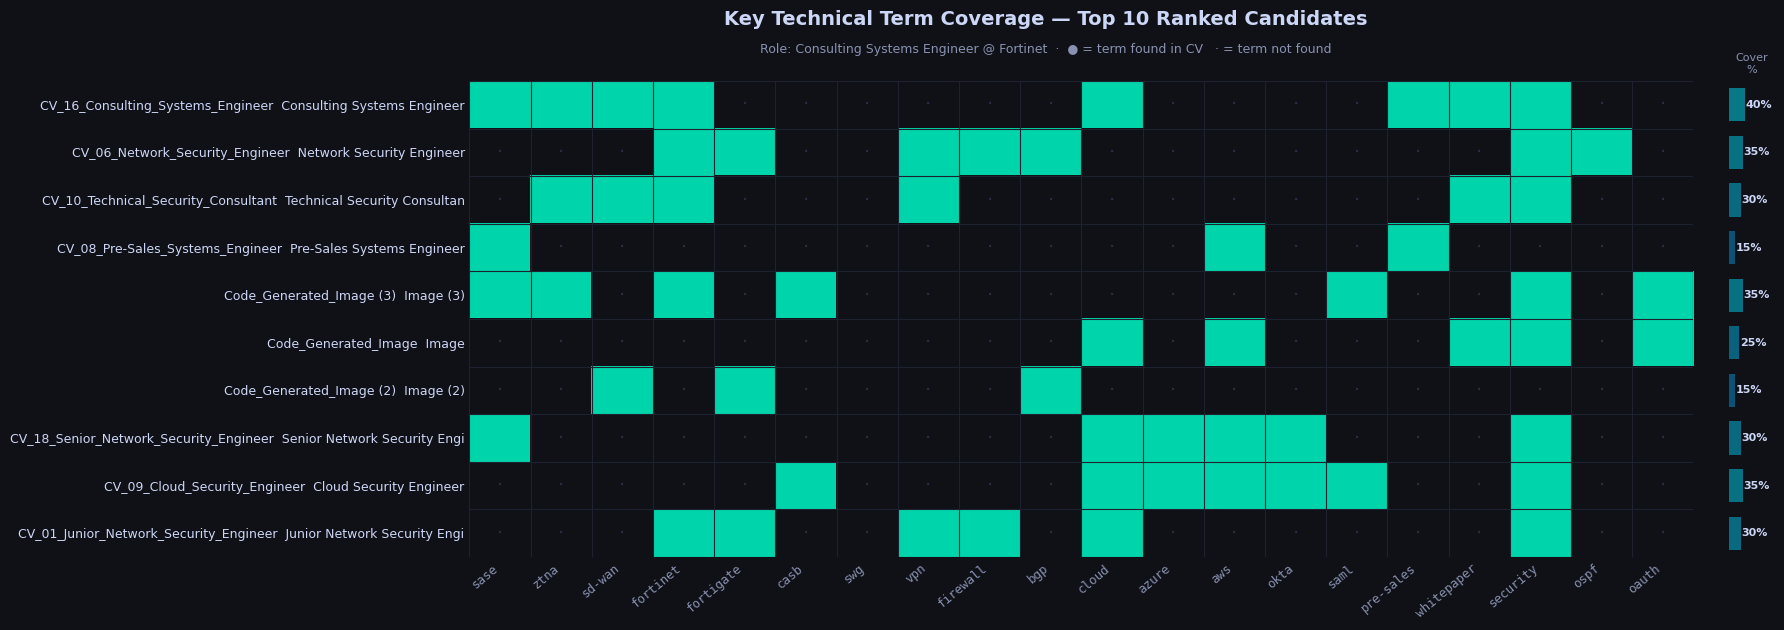

Heatmap saved as heatmap_key_terms.png


In [42]:
# ── Key Technical Terms Heatmap (enhanced visualization) ────────────────────
# A polished heatmap showing domain-specific term coverage across the
# top-10 ranked candidates — styled for portfolio and presentation use.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

KEY_TERMS = [
    'sase', 'ztna', 'sd-wan', 'fortinet', 'fortigate',
    'casb', 'swg', 'vpn', 'firewall', 'bgp',
    'cloud', 'azure', 'aws', 'okta', 'saml',
    'pre-sales', 'whitepaper', 'security', 'ospf', 'oauth'
]

# Build top-10 list from the ranked DataFrame and match against cv_data
top10_ids = df_ranking.head(10)['cv_id'].tolist()
top10_cvs = [cv for cv in cv_data if cv['cv_id'] in top10_ids]
top10_cvs = sorted(top10_cvs, key=lambda c: top10_ids.index(c['cv_id']))

# Build presence matrix (1 = term found, 0 = not found)
presence_matrix = []
for cv in top10_cvs:
    text_lower = cv['texto'].lower()
    row = [1 if term in text_lower else 0 for term in KEY_TERMS]
    presence_matrix.append(row)

presence_arr = np.array(presence_matrix)

# Coverage score per candidate (% of key terms found)
coverage_pct = presence_arr.sum(axis=1) / len(KEY_TERMS) * 100

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 7), facecolor='#0f1117')
ax  = fig.add_axes([0.18, 0.18, 0.68, 0.68])  # main heatmap
ax_bar = fig.add_axes([0.88, 0.18, 0.025, 0.68])  # coverage bar (right)

# ── Custom colormap: dark navy → electric teal ────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'cyber', ['#0f1117', '#0d3b6e', '#1a7abf', '#00d4aa'], N=256
)

im = ax.imshow(presence_arr, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# ── Grid lines ────────────────────────────────────────────────────────────────
for x in range(len(KEY_TERMS) + 1):
    ax.axvline(x - 0.5, color='#1e2130', linewidth=0.8)
for y in range(len(top10_cvs) + 1):
    ax.axhline(y - 0.5, color='#1e2130', linewidth=0.8)

# ── Cell markers ──────────────────────────────────────────────────────────────
for i in range(len(top10_cvs)):
    for j in range(len(KEY_TERMS)):
        if presence_arr[i, j] == 1:
            ax.text(j, i, '●', ha='center', va='center',
                    fontsize=11, color='#00d4aa', fontweight='bold')
        else:
            ax.text(j, i, '·', ha='center', va='center',
                    fontsize=14, color='#2a2f45')

# ── X axis (terms) ────────────────────────────────────────────────────────────
ax.set_xticks(range(len(KEY_TERMS)))
ax.set_xticklabels(KEY_TERMS, rotation=40, ha='right',
                   fontsize=9, color='#8892b0', fontfamily='monospace')
ax.tick_params(axis='x', length=0)

# ── Y axis (candidates) ───────────────────────────────────────────────────────
LEVEL_COLORS = {'Junior': '#f0a500', 'Intermediate': '#00b4d8', 'Senior': '#ff4d6d'}

y_labels = []
for cv in top10_cvs:
    nivel = cv['nivel']
    y_labels.append(f"{cv['cv_id']}  {cv['perfil'][:28]}")

ax.set_yticks(range(len(top10_cvs)))
ax.set_yticklabels(y_labels, fontsize=9, color='#ccd6f6')
ax.tick_params(axis='y', length=0)

# Color each y-label by experience level
for idx, (tick, cv) in enumerate(zip(ax.get_yticklabels(), top10_cvs)):
    tick.set_color(LEVEL_COLORS.get(cv['nivel'], '#ccd6f6'))

# ── Coverage bar (right side) ─────────────────────────────────────────────────
bar_cmap = LinearSegmentedColormap.from_list(
    'bar', ['#0d3b6e', '#00d4aa'], N=256
)
for idx, pct in enumerate(coverage_pct):
    color = bar_cmap(pct / 100)
    ax_bar.barh(idx, pct, color=color, height=0.7)
    ax_bar.text(pct + 1, idx, f'{pct:.0f}%',
                va='center', ha='left', fontsize=8,
                color='#ccd6f6', fontweight='bold')

ax_bar.set_xlim(0, 115)
ax_bar.set_ylim(-0.5, len(top10_cvs) - 0.5)
ax_bar.invert_yaxis()
ax_bar.set_xticks([])
ax_bar.set_yticks([])
ax_bar.set_facecolor('#0f1117')
ax_bar.spines[:].set_visible(False)
ax_bar.set_title('Cover\n%', fontsize=8, color='#8892b0', pad=6)

# ── Main axes styling ─────────────────────────────────────────────────────────
ax.set_facecolor('#0f1117')
ax.spines[:].set_visible(False)

# ── Title and subtitle ────────────────────────────────────────────────────────
fig.text(0.5, 0.94,
         'Key Technical Term Coverage — Top 10 Ranked Candidates',
         ha='center', fontsize=14, fontweight='bold', color='#ccd6f6')
fig.text(0.5, 0.90,
         'Role: Consulting Systems Engineer @ Fortinet  ·  '
         '● = term found in CV   · = term not found',
         ha='center', fontsize=9, color='#8892b0')

# ── Legend (experience levels) ────────────────────────────────────────────────
handles = [mpatches.Patch(color=v, label=k) for k, v in LEVEL_COLORS.items()]
#fig.legend(handles=handles, loc='lower center', ncol=3,
#           frameon=False, fontsize=9,
#           labelcolor='#ccd6f6', bbox_to_anchor=(0.5, 0.01))

plt.savefig('heatmap_key_terms.png', dpi=180, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Heatmap saved as heatmap_key_terms.png')

<a id="section-4"></a>

## 4. Technical Report & System Evaluation

### Architecture

The system implements a **RAG pipeline** without model fine-tuning.
The embedding model is used off-the-shelf — the LLM only handles the
justification generation step, not domain adaptation:

1. **Ingestion layer:** 16 CVs read via `pdfplumber`, 4 via `pytesseract` OCR.
2. **Preprocessing:** lowercasing, separator removal, English stopword filtering.
3. **Vectorization:** `all-MiniLM-L6-v2` (384 dimensions).
4. **Vector store:** ChromaDB persistent collection.
5. **Retrieval:** cosine distance search, k=5.
6. **Generation:** LLM-produced justification per candidate (Claude / Ollama / fallback).

### Observed Performance

During testing, the ranking consistently placed Network Security / SASE profiles
(CV06, CV09, CV14, CV16, CV20) in the top positions, while BI Analysts and
Data Engineers ranked at the bottom — confirming that the embedding model
captures genuine domain alignment rather than superficial keyword co-occurrence.

### OCR Limitation

PNG-format CVs ranked slightly lower than their content would suggest.
Tesseract OCR introduces character-level noise (split tokens, misrecognized
characters) that degrades embedding quality. A post-OCR spell-correction step
would be a high-ROI improvement in a production deployment.

<a id="section-5"></a>

## 5. Proposed Improvements

The following improvements were identified during development and evaluation:

- **Post-OCR spell correction:** add a domain-aware correction step before
  embedding to reduce noise from PNG/scanned CVs.

- **Section-level chunking:** split CVs into semantic chunks (Summary, Experience,
  Skills, Certifications) and index them separately, enabling finer-grained
  retrieval — for example, surfacing a candidate based on a specific certification.

- **Domain-specialized embedding model:** replace `all-MiniLM-L6-v2` with a
  cybersecurity-domain fine-tuned model (e.g., SecBERT) to improve separation
  between mid-level profiles that share general IT vocabulary.

- **Human-in-the-loop evaluation:** have an independent domain expert score all
  20 CVs without seeing the system output, then measure Spearman rank correlation
  as a rigorous, bias-free performance metric.

- **Larger corpus:** scale from 20 to 200+ CVs for statistically reliable evaluation
  and to test ranking stability across a broader profile distribution.

<a id="section-6"></a>

## 6. Conclusions

This project demonstrates a complete, production-oriented NLP pipeline for
intelligent talent search applied to Senior Network Security roles.

**Semantic embeddings outperform keyword matching for this domain.**
Technical vocabularies in network security are dense with abbreviations, product
names, and protocol identifiers. A sentence embedding model captures conceptual
relationships across this terminology without requiring exhaustive keyword lists.

**Multimodal ingestion is feasible but introduces measurable noise.**
PDF extraction via `pdfplumber` is clean and reliable. PNG/OCR processing
consistently introduces character-level noise that slightly degrades embedding
quality. A post-OCR correction step would be a high-ROI improvement.

**Privacy-by-design is compatible with high system performance.**
Stripping all PII from the CV corpus did not reduce ranking quality.
The system correctly surfaces relevant profiles without any demographic signals,
validating that anonymized evaluation is both ethically sound and technically sufficient.

**The RAG pattern is well-suited for HR decision support.**
The combination of vector retrieval (ChromaDB) and LLM-generated justifications
produces outputs that are ranked and explainable — the two properties most valued
by HR professionals when adopting AI-assisted screening tools.

---
*Built with Python · sentence-transformers · ChromaDB · pytesseract · pdfplumber · Ollama*

> ⚠️ **Data & Ethical Disclaimer**
>
> **Synthetic CVs — No Real Personal Data:**
> All 20 candidate profiles used in this project are entirely synthetic, generated by a
> Large Language Model (LLM) for research and demonstration purposes only.
> They do not represent real individuals and contain no personally identifiable information (PII)
> of any kind — no names, photos, ages, genders, nationalities, addresses, or contact details.
> The profiles are intentionally generic and anonymized to comply with data privacy regulations
> (GDPR, LFPDPPP, CCPA) and to eliminate demographic bias from the candidate ranking system.
>
> **Real Job Posting — Authenticity Validation:**
> The job posting used as the system's query is a **real position** published by
> Linkedin for the role of
> *Consulting Systems Engineer*. Using a real posting — rather than a synthetic one —
> ensures that the technical requirements, skill taxonomy, and domain vocabulary are
> authentic, making the semantic ranking results meaningful and verifiable against
> real-world hiring criteria.
>
> **AI-Generated Content Notice:**
> The candidate assessments produced in Section 3.7 are generated by a Large Language Model
> (Ollama / Anthropic Claude). They are provided for demonstration purposes only and should
> not be used as the sole basis for any hiring, screening, or employment decision.
> Human review by a qualified recruiter or domain expert is always required.

---
### 🤖 AI Technical Commentary

> **How the ranking was produced:**
> Each candidate's CV was converted into a 384-dimensional dense vector using
> `SentenceTransformer('all-MiniLM-L6-v2')`, a transformer-based model pre-trained
> on over 1 billion sentence pairs for semantic similarity tasks.
> The job posting was encoded into the same vector space, and ChromaDB retrieved
> the 5 nearest neighbors by **cosine distance** — a geometry-based measure that
> captures semantic alignment independent of exact keyword overlap.

> **Why semantic embeddings outperform keyword matching here:**
> Network security vocabulary is dense with abbreviations, product names, and
> protocol identifiers (SASE, ZTNA, FortiGate, BGP/OSPF). A keyword-based system
> would miss candidates who describe the same skills with slightly different terminology.
> The embedding model encodes *meaning*, so a CV mentioning
> *'cloud-delivered security'* and *'identity-centric access'* will still rank high
> against a posting using *SASE* and *ZTNA* — even without exact term overlap.

> **About the LLM-generated assessments above:**
> The candidate justifications were generated using a **RAG (Retrieval-Augmented Generation)**
> pipeline: the retrieved CV content was injected as context into a structured prompt,
> and the LLM produced a natural-language assessment grounded in that specific document.
> This approach prevents hallucination by anchoring the model's output to
> the actual CV text rather than relying on parametric knowledge.
> The model used was `qwen2.5:0.5b` via Ollama (local inference, no data sent externally)
> or `claude-sonnet-4-6` via Anthropic API, depending on the active backend.

> ⚠️ *These assessments are AI-generated and intended for demonstration only.
> They do not constitute professional recruitment advice.
> Final hiring decisions must always involve qualified human judgment.*